### 用到 九江 PCA101A 上试试效果

In [3]:
import torch
import argparse
import pandas as pd
import matplotlib.pyplot as plt

from models import timer_xl

In [4]:
# init the args of pre-trained Timer-XL

args = argparse.Namespace()
args.input_token_len = 96
args.output_token_len = 96
args.d_model = 1024
args.n_heads = 8
args.e_layers = 8
args.d_ff = 2048
args.dropout = 0.1
args.activation = 'relu'
args.use_norm = True
args.flash_attention = False
args.covariate = False
args.output_attention = False

model = timer_xl.Model(args)

# download the checkpoint from https://cloud.tsinghua.edu.cn/f/01c35ca13f474176be7b/
model.load_state_dict(torch.load('checkpoint.pth')) 

/home/aicode/miniconda3/envs/tsfm/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


<All keys matched successfully>

In [5]:
# evaluate zere-shot prediction

df = pd.read_csv("../dataset/JJ/PCA101A/2FCC_PCA101A_smooth_testing1_long.csv")

lookback_length = 1440      # support the maximum context length up to 2880 
input = torch.tensor(df.iloc[:,-1][:lookback_length]).unsqueeze(0).float()

# generate forecast 
prediction_length = 96     # forecast the next 96 timestamps, supporting maximum prediction length encompassed in the context length

output =  model(input.unsqueeze(-1), None, None)

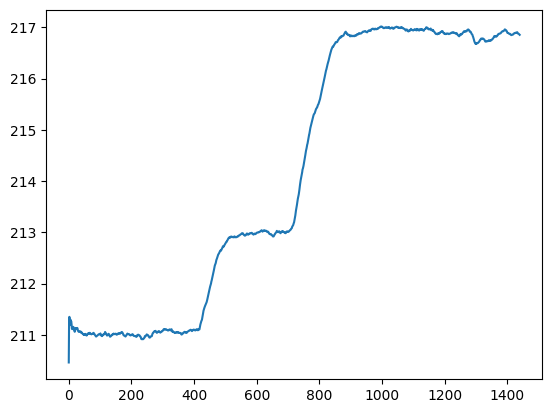

In [6]:
plt.plot(input.squeeze().detach().numpy())

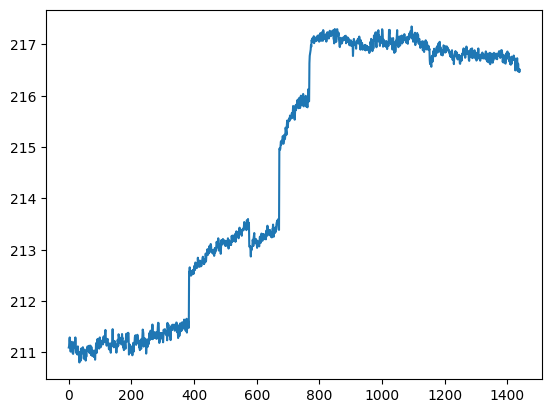

In [7]:
plt.plot(output.squeeze().detach().numpy())

In [8]:
# Note that the output is the whole sequence of next token prediction
# so we need to select the last token (token_len=96) as the final prediction

pred = output[:, -prediction_length:, 0].squeeze().detach().numpy()

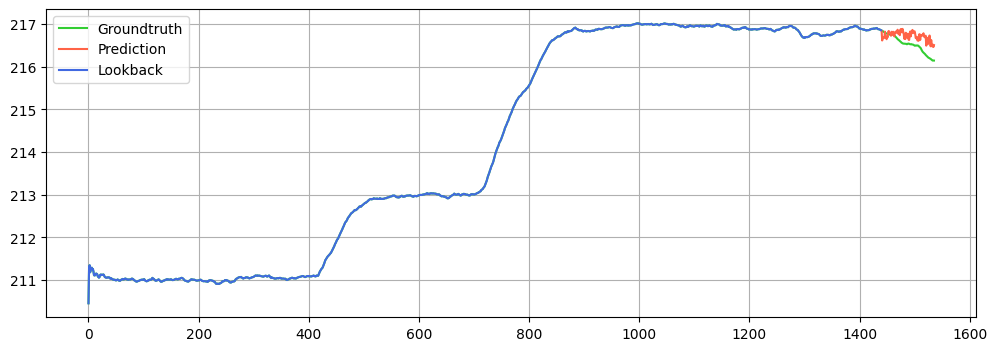

In [9]:
# plot the prediction

plt.figure(figsize=(12, 4))
plt.plot(df.iloc[:,-1][:lookback_length + prediction_length], color="limegreen", label="Groundtruth")
plt.plot(range(lookback_length, lookback_length + prediction_length), pred, color="tomato", label="Prediction")
plt.plot(df.iloc[:,-1][:lookback_length], color="royalblue", label="Lookback")
plt.legend()
plt.grid()
plt.show()

## Part A: M→M 多变量预测多变量

复用已加载的 `model` (covariate=False)。把 CSV 全部 6 列同时作为输入，预测未来 96 步。

In [10]:
# === A1: M→M 推理。把全部 6 列同时输入模型 ===
all_cols = df.columns.tolist()
print("输入变量:", all_cols, " (最后一列为目标)")

mv_input = torch.tensor(df[all_cols].iloc[:lookback_length].values).unsqueeze(0).float()
print("MV input shape:", tuple(mv_input.shape))   # 期望 (1, 1536, 6)

with torch.no_grad():
    mv_output = model(mv_input, None, None)
print("MV output shape:", tuple(mv_output.shape)) # 期望 (1, L, 6)

mv_pred = mv_output[:, -prediction_length:, :].squeeze(0).detach().numpy()  # [96, 6]
print("MV pred shape:", mv_pred.shape)


输入变量: ['0202B_PI002', '0202B_PIA004', '0202B_PI108F', '0202B_PC1120', '0202B_PI003', '0202B_PCA101A']  (最后一列为目标)
MV input shape: (1, 1440, 6)
MV output shape: (1, 1440, 6)
MV pred shape: (96, 6)


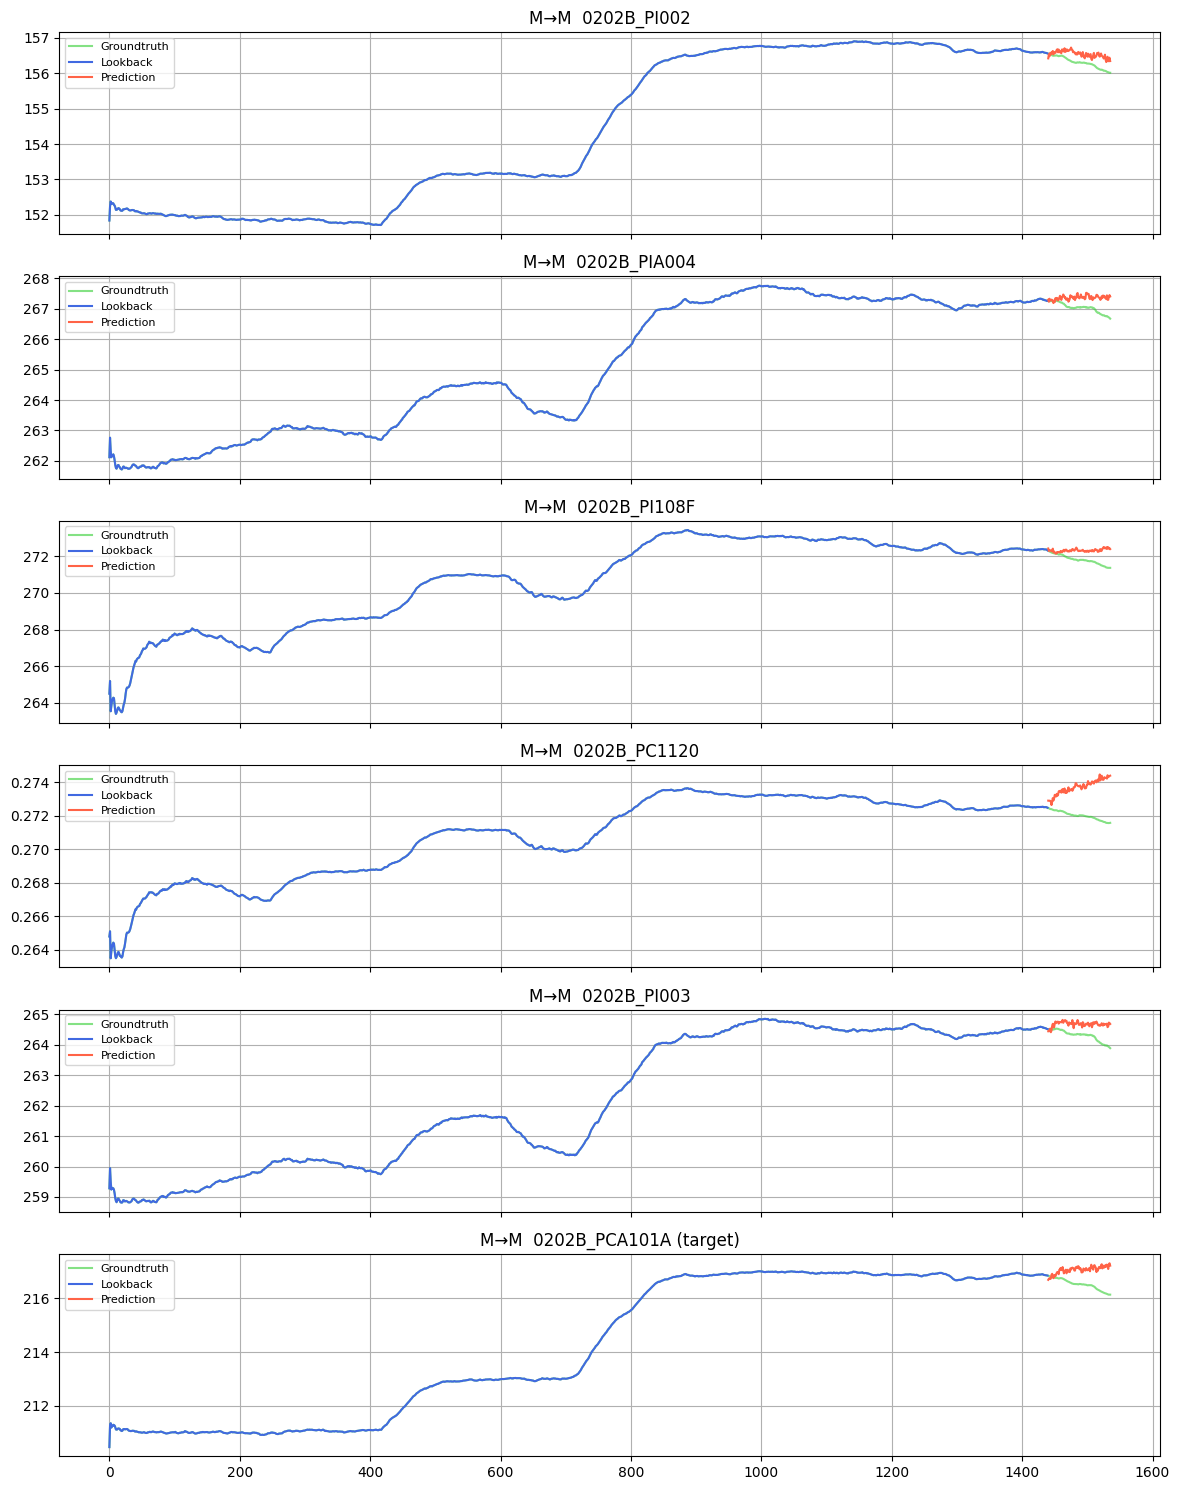

In [11]:
# === A2: 多通道分别画图 ===
fig, axes = plt.subplots(len(all_cols), 1, figsize=(12, 2.5 * len(all_cols)), sharex=True)
for i, col in enumerate(all_cols):
    gt = df[col].iloc[:lookback_length + prediction_length].values
    lookback = df[col].iloc[:lookback_length].values
    ch_pred = mv_pred[:, i]
    axes[i].plot(gt, color="limegreen", label="Groundtruth", alpha=0.6)
    axes[i].plot(lookback, color="royalblue", label="Lookback")
    axes[i].plot(range(lookback_length, lookback_length + prediction_length),
                 ch_pred, color="tomato", label="Prediction")
    title_suffix = " (target)" if i == len(all_cols) - 1 else ""
    axes[i].set_title(f"M→M  {col}{title_suffix}")
    axes[i].grid(True)
    axes[i].legend(loc="upper left", fontsize=8)
plt.tight_layout()
plt.show()


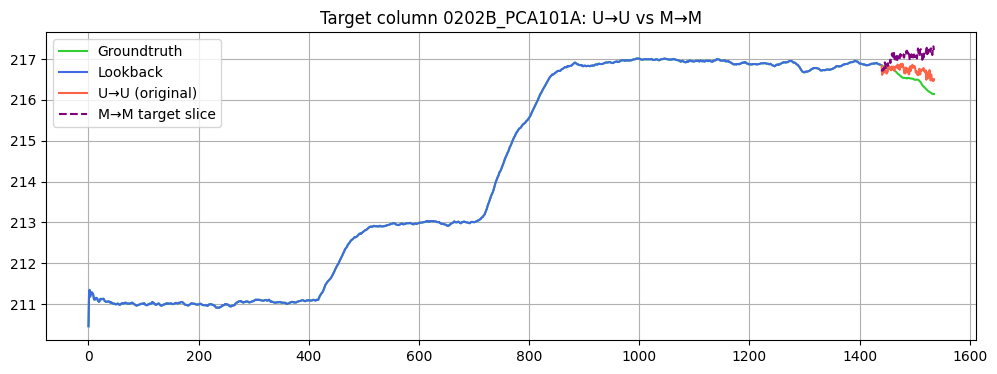

In [12]:
# === A3: 目标列 U→U vs M→M 对比 ===
# pred 是上面 cell 里 U→U 原始预测 (df.iloc[:, -1] 单变量)
plt.figure(figsize=(12, 4))
plt.plot(df.iloc[:, -1][:lookback_length + prediction_length], color="limegreen", label="Groundtruth")
plt.plot(df.iloc[:, -1][:lookback_length], color="royalblue", label="Lookback")
plt.plot(range(lookback_length, lookback_length + prediction_length),
         pred, color="tomato", label="U→U (original)")
plt.plot(range(lookback_length, lookback_length + prediction_length),
         mv_pred[:, -1], color="purple", linestyle="--", label="M→M target slice")
plt.title("Target column 0202B_PCA101A: U→U vs M→M")
plt.legend()
plt.grid()
plt.show()


## Part B: Covariate 模式 M→1 预测

重建一个 `covariate=True` 的 model 实例（复用同一个 checkpoint）。
Timer-XL 的 `TimerCovariateMask` 会让最后一列（目标）只从历史协变量里取信息，详见 `utils/masking.py:24-35`。

⚠️ 官方 ckpt 未必是用 covariate=True 训练的，可能有训练-推理 gap。用 cell B4 的指标对比评估。

In [13]:
# === B1: 重建模型并切换到 covariate 模式 ===
import copy
args_cov = copy.copy(args)
args_cov.covariate = True

model_cov = timer_xl.Model(args_cov)
model_cov.load_state_dict(torch.load('checkpoint.pth'))
model_cov.eval()
print("Covariate model loaded. covariate flag =", args_cov.covariate)


Covariate model loaded. covariate flag = True


In [14]:
# === B2: Covariate 推理。目标列位于最后一列（已天然满足） ===
cov_input = torch.tensor(df[all_cols].iloc[:lookback_length].values).unsqueeze(0).float()
print("Cov input shape:", tuple(cov_input.shape))

with torch.no_grad():
    cov_output_full = model_cov(cov_input, None, None)
print("Cov output shape:", tuple(cov_output_full.shape))

# 取最后一列作为目标预测，参考 exp/exp_forecast.py:88-94
cov_pred = cov_output_full[:, -prediction_length:, -1].squeeze(0).detach().numpy()  # [96]
print("Cov pred shape:", cov_pred.shape)


Cov input shape: (1, 1440, 6)
Cov output shape: (1, 1440, 6)
Cov pred shape: (96,)


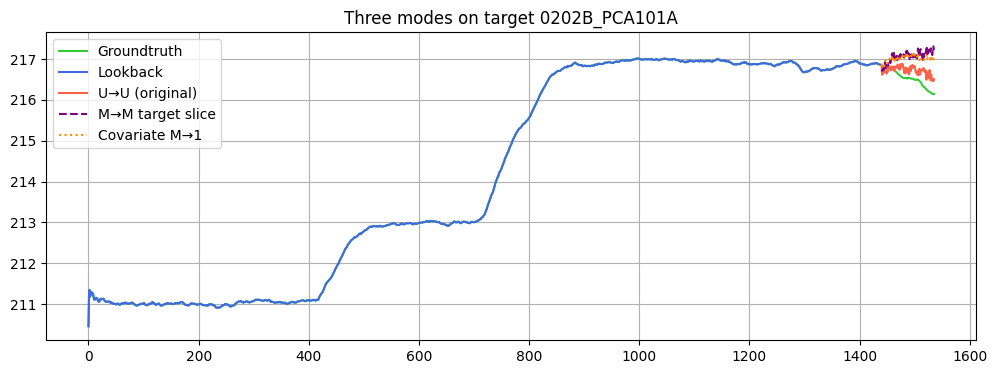

In [15]:
# === B3: 三种模式同图对比 ===
plt.figure(figsize=(12, 4))
plt.plot(df.iloc[:, -1][:lookback_length + prediction_length], color="limegreen", label="Groundtruth")
plt.plot(df.iloc[:, -1][:lookback_length], color="royalblue", label="Lookback")
plt.plot(range(lookback_length, lookback_length + prediction_length),
         pred, color="tomato", label="U→U (original)")
plt.plot(range(lookback_length, lookback_length + prediction_length),
         mv_pred[:, -1], color="purple", linestyle="--", label="M→M target slice")
plt.plot(range(lookback_length, lookback_length + prediction_length),
         cov_pred, color="darkorange", linestyle=":", label="Covariate M→1")
plt.title("Three modes on target 0202B_PCA101A")
plt.legend()
plt.grid()
plt.show()


In [16]:
# === B4: MAE / MSE 指标对比 ===
import numpy as np
gt = df.iloc[:, -1][lookback_length:lookback_length + prediction_length].values

def metrics(name, p):
    mae = float(np.mean(np.abs(p - gt)))
    mse = float(np.mean((p - gt) ** 2))
    print(f"{name:25s}  MAE={mae:.4f}  MSE={mse:.4f}")

metrics("U→U (original)", pred)
metrics("M→M target slice", mv_pred[:, -1])
metrics("Covariate M→1", cov_pred)


U→U (original)             MAE=0.2184  MSE=0.0642
M→M target slice           MAE=0.5484  MSE=0.3868
Covariate M→1              MAE=0.4804  MSE=0.2861


## Part C: 加载微调后的 checkpoint 对比

从 `checkpoints/` 加载全量微调后的 U 和 Co 模型，与上面零样本结果对比。

In [18]:
# === C1: 加载微调后的 U 模型（单变量） ===
import copy

ckpt_u_path = 'checkpoints/forecast_PCA101A_U_full_shot_timer_xl_MultivariateDatasetYAMLSplit_sl1440_it96_ot96_lr5e-06_bt32_wd0_el8_dm1024_dff2048_nh8_cosTrue_test_0/checkpoint.pth'

model_ft_u = timer_xl.Model(args)  # covariate=False
model_ft_u.load_state_dict(torch.load(ckpt_u_path))
model_ft_u.eval()

# 单变量推理（和原始 U→U 一样，只用目标列）
with torch.no_grad():
    ft_u_output = model_ft_u(input.unsqueeze(-1), None, None)

ft_u_pred = ft_u_output[:, -prediction_length:, 0].squeeze().detach().numpy()
print("Fine-tuned U pred shape:", ft_u_pred.shape)

Fine-tuned U pred shape: (96,)


In [19]:
# === C2: 加载微调后的 Co 模型（协变量） ===
args_cov_ft = copy.copy(args)
args_cov_ft.covariate = True

ckpt_co_path = 'checkpoints/forecast_PCA101A_Co_full_shot_timer_xl_MultivariateDatasetYAMLSplit_sl1440_it96_ot96_lr5e-06_bt32_wd0_el8_dm1024_dff2048_nh8_cosTrue_test_0/checkpoint.pth'

model_ft_co = timer_xl.Model(args_cov_ft)
model_ft_co.load_state_dict(torch.load(ckpt_co_path))
model_ft_co.eval()

# 多变量输入，只取目标列预测
cov_input_ft = torch.tensor(df[all_cols].iloc[:lookback_length].values).unsqueeze(0).float()
with torch.no_grad():
    ft_co_output = model_ft_co(cov_input_ft, None, None)

ft_co_pred = ft_co_output[:, -prediction_length:, -1].squeeze().detach().numpy()
print("Fine-tuned Co pred shape:", ft_co_pred.shape)

Fine-tuned Co pred shape: (96,)


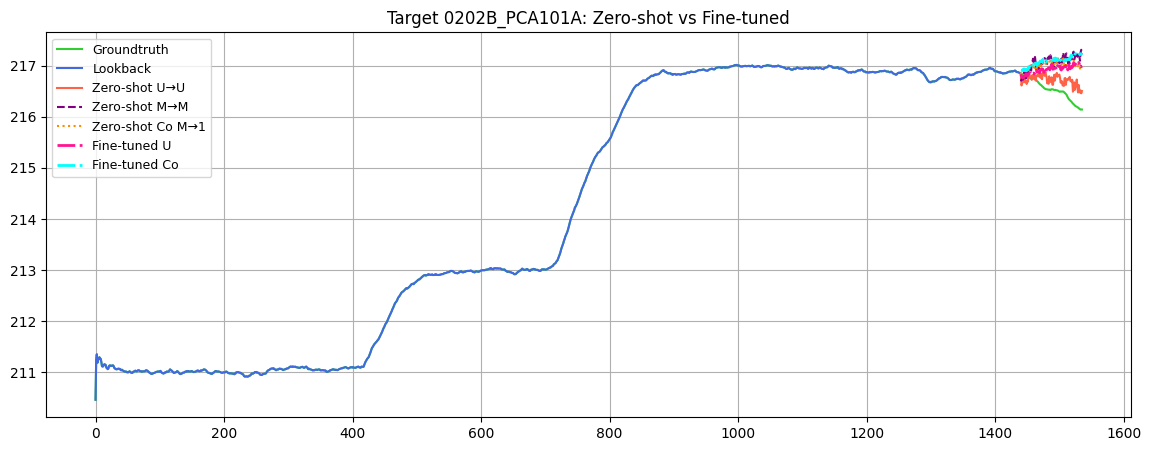

In [20]:
# === C3: 全部五种模式同图对比 ===
plt.figure(figsize=(14, 5))
plt.plot(df.iloc[:, -1][:lookback_length + prediction_length], color="limegreen", label="Groundtruth")
plt.plot(df.iloc[:, -1][:lookback_length], color="royalblue", label="Lookback")

# 零样本
plt.plot(range(lookback_length, lookback_length + prediction_length),
         pred, color="tomato", label="Zero-shot U→U")
plt.plot(range(lookback_length, lookback_length + prediction_length),
         mv_pred[:, -1], color="purple", linestyle="--", label="Zero-shot M→M")
plt.plot(range(lookback_length, lookback_length + prediction_length),
         cov_pred, color="darkorange", linestyle=":", label="Zero-shot Co M→1")

# 微调后
plt.plot(range(lookback_length, lookback_length + prediction_length),
         ft_u_pred, color="deeppink", linestyle="-.", linewidth=2, label="Fine-tuned U")
plt.plot(range(lookback_length, lookback_length + prediction_length),
         ft_co_pred, color="cyan", linestyle="-.", linewidth=2, label="Fine-tuned Co")

plt.title("Target 0202B_PCA101A: Zero-shot vs Fine-tuned")
plt.legend(fontsize=9)
plt.grid()
plt.show()

In [21]:
# === C4: MAE / MSE 指标对比（零样本 vs 微调） ===
print(f"{'Model':30s}  {'MAE':>8s}  {'MSE':>8s}")
print("-" * 52)
metrics("Zero-shot U→U", pred)
metrics("Zero-shot M→M (target)", mv_pred[:, -1])
metrics("Zero-shot Co M→1", cov_pred)
metrics("Fine-tuned U", ft_u_pred)
metrics("Fine-tuned Co", ft_co_pred)

Model                                MAE       MSE
----------------------------------------------------
Zero-shot U→U              MAE=0.2184  MSE=0.0642
Zero-shot M→M (target)     MAE=0.5484  MSE=0.3868
Zero-shot Co M→1           MAE=0.4804  MSE=0.2861
Fine-tuned U               MAE=0.4019  MSE=0.2285
Fine-tuned Co              MAE=0.5547  MSE=0.3896
